## K-Means clustering and Pricipal Compoent Analysis.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from random import sample
import scipy.misc
import matplotlib.cm as cm
from scipy import linalg


/tmp/ipython-input-4276605925.py:6: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


## K means Clustering.

### Implementing K-Means
#### Finding the closest centroid.


In [3]:
datafile = '/content/data/ex7data2.mat'
mat = scipy.io.loadmat(datafile)
X = mat['X']


In [4]:
K = 3
# choose the centroid
initial_centroids = np.array([[3, 3], [6, 2], [8, 5]])

In [5]:
def plotData(myX, mycentroids_history, myidxs=None):
    """
    Plot data points and centroid movements for K-means.
    myX: (m, n_features)
    mycentroids_history: list of arrays [(K, n_features), ...] for each iteration
    myidxs: cluster assignments (optional)
    """
    import matplotlib.pyplot as plt
    import numpy as np

    colors = ['b','g','gold','darkorange','salmon','olivedrab']
    K = mycentroids_history[0].shape[0]
    assert K <= len(colors)

    plt.figure(figsize=(7, 5))

    # If cluster indices supplied, split points by cluster
    if myidxs is not None:
        for k in range(K):
            cluster_points = myX[myidxs.ravel() == k, :]
            plt.plot(cluster_points[:, 0], cluster_points[:, 1], 'o',
                     color=colors[k], alpha=0.75, label=f'Cluster {k}')
    else:
        plt.plot(myX[:, 0], myX[:, 1], 'o', color='blue', alpha=0.75, label='Data Points')

    plt.xlabel('x1', fontsize=14)
    plt.ylabel('x2', fontsize=14)
    plt.title('Plot of X points', fontsize=16)
    plt.grid(True)

    # Draw centroid movements
    tempx = np.array([c[:, 0] for c in mycentroids_history])
    tempy = np.array([c[:, 1] for c in mycentroids_history])
    for k in range(K):
        plt.plot(tempx[:, k], tempy[:, k], 'rx--', markersize=8)

    plt.legend(framealpha=0.5)
    plt.show()


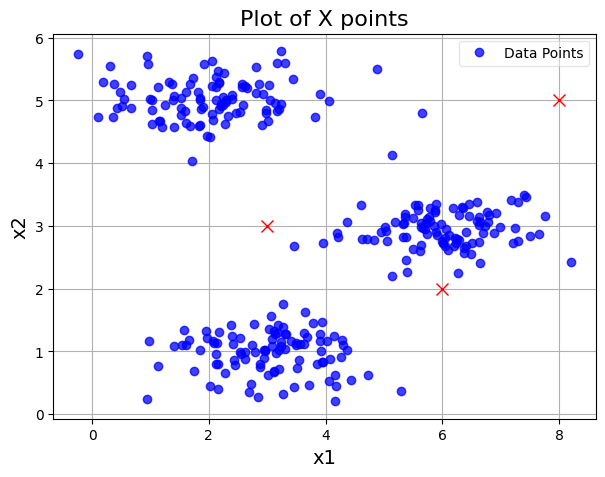

In [6]:
plotData(X,[initial_centroids])

In [7]:
def distSquared(point1, point2):
  assert point1.shape == point2.shape
  return np.sum(np.square(point2-point1))

In [8]:
def findClosestCentroids(myX, mycentroids):
  """
  Function takes in the (m,n) X matrix
  (where m is the # of points, n is # of features per point)
  and the (K,n) centroid seed matrix
  (where K is the # of centroids (clusters)
  and returns a (m,1) vector of cluster indices
  per point in X (0 through K-1)
  """

  idxs = np.zeros((myX.shape[0], 1))

  # Loop through each data point in X
  for x in range(idxs.shape[0]):
    mypoint = myX[x]
    # Compare this point to each centroid
    # Keep track of shortest distance and index of shortest distance.

    mindist, idx = 9999999, 0
    for i  in range(mycentroids.shape[0]):
      mycentroid = mycentroids[i]
      distsquared = distSquared(mycentroid, mypoint)
      if distsquared < mindist:
        mindist = distsquared
        idx = i
    # with the best index found, modify the result idx vector

    idxs[x]  = idx

  return idxs


In [9]:
idxs = findClosestCentroids(X, initial_centroids)

print(idxs[:3].flatten())


[0. 2. 1.]


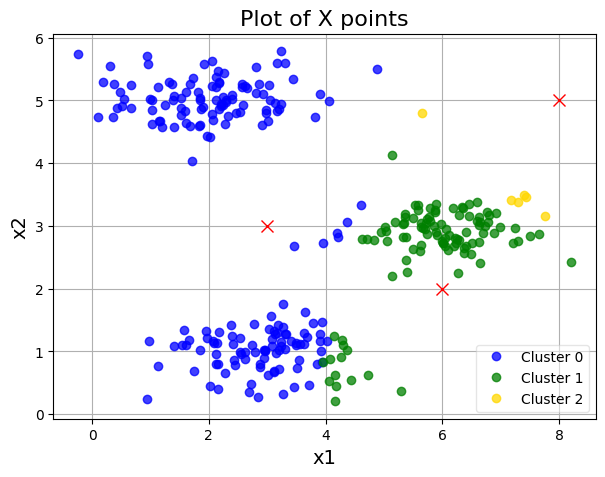

In [10]:
plotData(X, [initial_centroids], idxs)

### Computing Centroid Means.

In [16]:
def computeCentroids(myX, myidxs):
  """ Function takes in the X matrix and the index vector
  and computes a new centroid matrix.
  """
  subX = []
  for x  in range(len(np.unique(myidxs))):
    subX.append(np.array([myX[i] for i in range(myX.shape[0]) if myidxs[i] == x]))

  return np.array([np.mean(thisX, axis=0) for thisX in subX])


### K-Means on example dataset.

In [17]:
def runKMeans(myX, initial_centroids, K, n_iter):
  """
  functon that actually does the iteration
  """
  centroid_history = []
  current_centroids = initial_centroids
  for myiter in range(n_iter):
    centroid_history.append(current_centroids)
    idxs = findClosestCentroids(myX, current_centroids)
    current_centroids = computeCentroids(myX, idxs)

  return idxs, centroid_history


In [18]:
idxs, centroid_history = runKMeans(X,initial_centroids,K=3,n_iter=10)

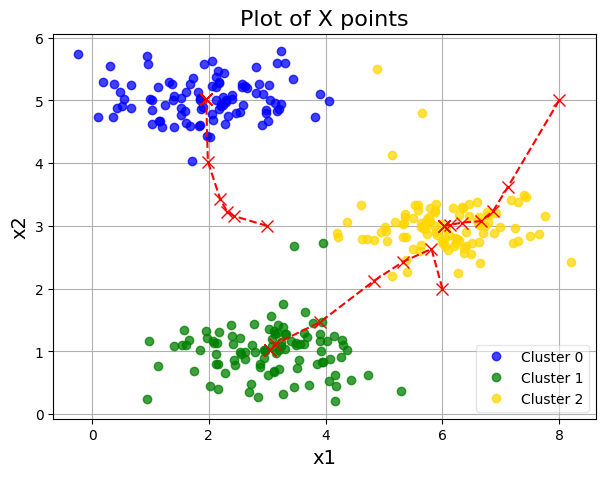

In [19]:
plotData(X, centroid_history, idxs)

#### Random Initialization.

In [20]:
def chooseRandomCentroids(myX, K):
  rand_indices = sample(range(0, myX.shape[0]), K)
  return np.array([myX[i] for i in rand_indices])

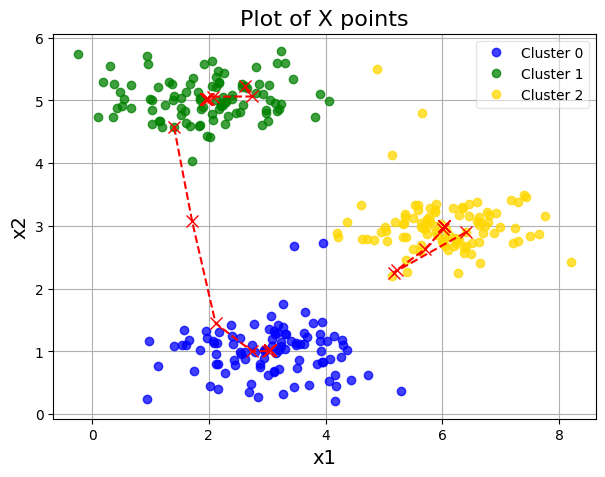

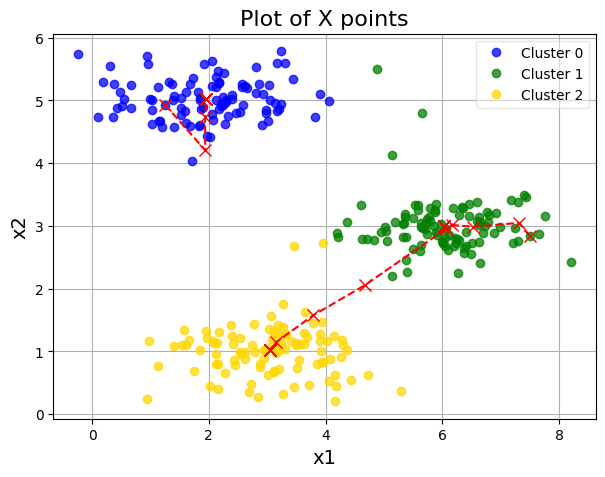

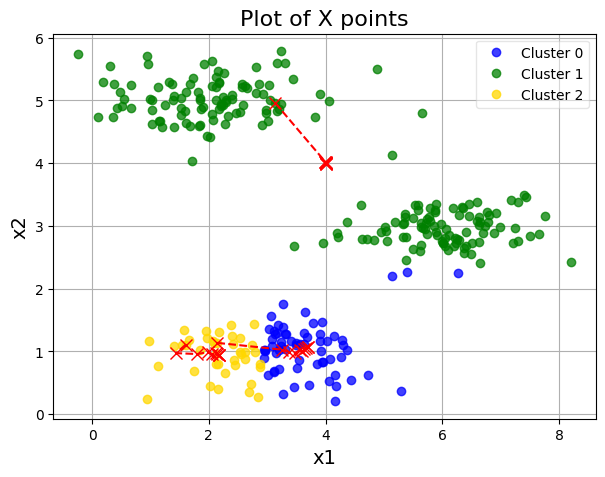

In [21]:
#Let's choose random initial centroids and see the resulting  centriod progression plot..
# Perhaps three-times in a row.

for x in range(3):
  idxs, centroid_history = runKMeans(X, chooseRandomCentroids(X, K=3),
                                     K=3,n_iter=10)

  plotData(X, centroid_history, idxs)

### Image Compression with K-means.
 #### K-means on pixels.

A shape is (128, 128, 3)


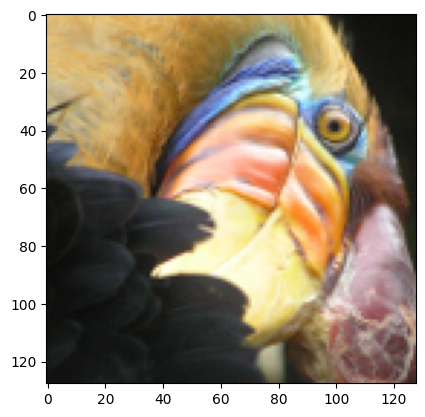

In [25]:
import imageio.v2 as imageio

datafile = '/content/data/bird_small.png'

A = imageio.imread(datafile)
print("A shape is", A.shape)
dummy = plt.imshow(A)

In [31]:
def chooseKRandomCentroids(myX, K):
    rand_indices = sample(range(0,myX.shape[0]),K)
    return np.array([myX[i] for i in rand_indices])


In [32]:
A = A / 255.

A = A.reshape(-1, 3)

# Run k-means on this data forming 16 clusteds , with random initializatioin.

myK = 16
idxs, centroid_history = runKMeans(A, chooseKRandomCentroids(A, myK),
                                                             myK, n_iter=10)

In [33]:
idxs = findClosestCentroids(A, centroid_history[-1])

In [37]:
final_centroids = centroid_history[-1]
# Now loop through the original image and form a new image
# that only has 16 colors in it
final_image = np.zeros((idxs.shape[0],3))
for x in range(final_image.shape[0]):
    final_image[x] = final_centroids[int(idxs[x])]



/tmp/ipython-input-2838140712.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  final_image[x] = final_centroids[int(idxs[x])]


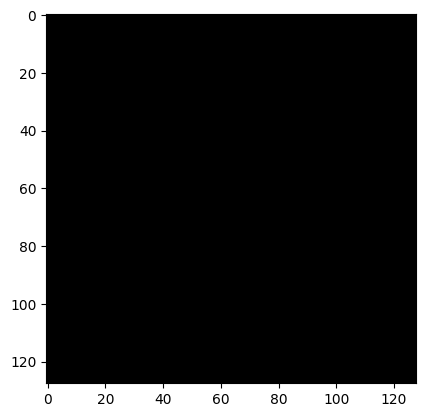

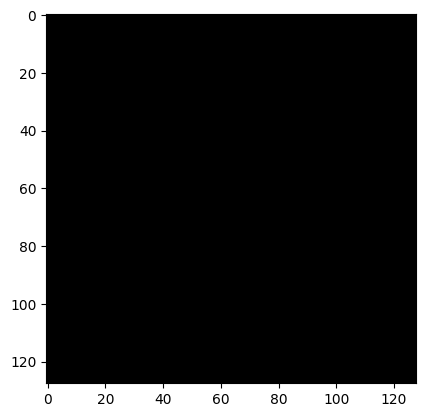

In [38]:
# Reshape the original image and the new, final image and draw them
# To see what the "compressed" image looks like
plt.figure()
dummy = plt.imshow(A.reshape(128, 128, 3))

plt.figure()
dummy = plt.imshow(final_image.reshape(128, 128, 3))
#

### Principle Component Analysis

### Example dataset.


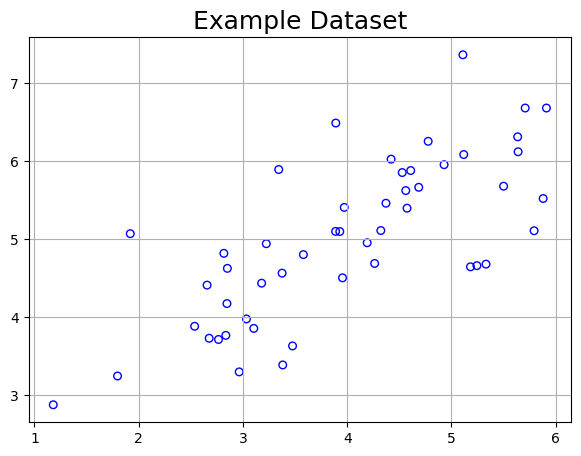

In [39]:
datafile = '/content/data/ex7data1.mat'

mat = scipy.io.loadmat(datafile)
X = mat['X']

plt.figure(figsize=(7, 5))
plot = plt.scatter(X[:, 0], X[:, 1], s=30, facecolors='none', edgecolors='b')
plt.title('Example Dataset', fontsize=18)
plt.grid(True)

## Implementing PCA


In [49]:
def featureNormalize(myX):
  # Feature-normalize X, return it.
  means = np.mean(myX, axis=0)
  myX_norm = myX - means
  stds = np.std(myX_norm, axis=0)
  myX_norm = myX_norm / stds
  return means, stds, myX_norm

In [51]:
def getUSV(myX_norm):
  # Compute the covariance matrix
  cov_matrix = myX_norm.T.dot(myX_norm)/ myX_norm.shape[0]
  # Run the single value decomposition to get the U pricipal component matrix
  U, S, V = linalg.svd(cov_matrix, full_matrices=True, compute_uv=True)
  return U, S, V


In [52]:
# Feature normalize
means, stds, X_norm = featureNormalize(X)
# Run SVD
U, S, V = getUSV(X_norm)


Top principal component is [-0.70710678 -0.70710678]


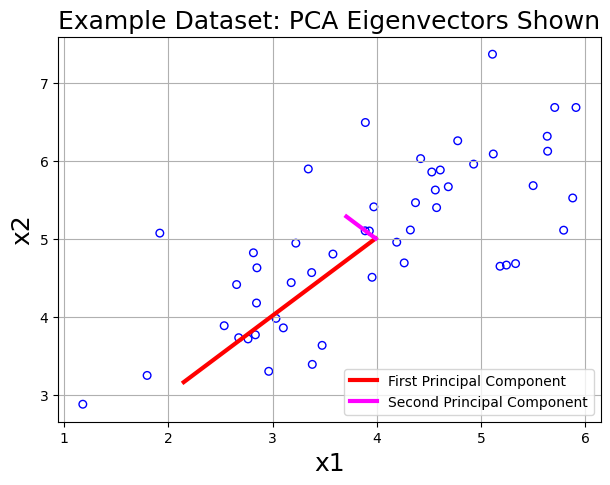

In [54]:
# "...output the top principal component (eigen- vector) found,
# and you should expect to see an output of about [-0.707 -0.707]"
print('Top principal component is',U[:,0])

#Quick plot, now including the principal component
plt.figure(figsize=(7,5))
plot = plt.scatter(X[:,0], X[:,1], s=30, facecolors='none', edgecolors='b')
plt.title("Example Dataset: PCA Eigenvectors Shown",fontsize=18)
plt.xlabel('x1',fontsize=18)
plt.ylabel('x2',fontsize=18)
plt.grid(True)
#To draw the principal component, you draw them starting
#at the mean of the data
plt.plot([means[0], means[0] + 1.5*S[0]*U[0,0]],
         [means[1], means[1] + 1.5*S[0]*U[0,1]],
        color='red',linewidth=3,
        label='First Principal Component')
plt.plot([means[0], means[0] + 1.5*S[1]*U[1,0]],
         [means[1], means[1] + 1.5*S[1]*U[1,1]],
        color='fuchsia',linewidth=3,
        label='Second Principal Component')
leg = plt.legend(loc=4)

### Dimensionality Reduction with PCA
###  Projecting the data onto the principal components

In [55]:
def projectData(myX, myU, K):
  """
  Function that computes the reduced data representation when
  projecting only on to the top "K" eigenvectors
  """

  # Reduced U is the first "K" columns in U.
  Ureduced = myU[:,:K]
  z = myX.dot(Ureduced)
  return z

In [56]:
# "...project the first example onto the first dimension  and we should see a value of about 1.481
z = projectData(X_norm, U, 1)
print("Projection of the first example is %0.3f" %float(z[0]))

Projection of the first example is 1.496


/tmp/ipython-input-4165971003.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Projection of the first example is %0.3f" %float(z[0]))


### Reconstructing an approximation of the data.


In [57]:
def recoverData(myZ, myU, K):
  Ureduced = myU[:, :K]
  Xapprox = myZ.dot(Ureduced.T)
  return Xapprox

In [58]:
X_rec = recoverData(z,U,1)
print("Recovered approximation of the frist example is ", X_rec[0])

Recovered approximation of the frist example is  [-1.05805279 -1.05805279]


##### Visualizing the projections



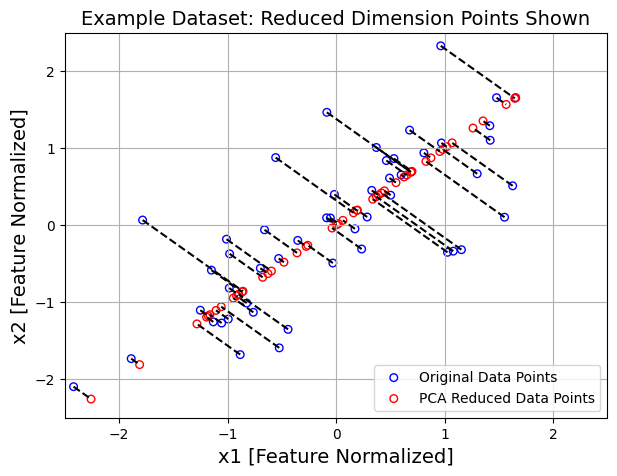

In [62]:
#Quick plot, now drawing projected points to the original points
plt.figure(figsize=(7,5))
plot = plt.scatter(X_norm[:,0], X_norm[:,1], s=30, facecolors='none',
                   edgecolors='b',label='Original Data Points')
plot = plt.scatter(X_rec[:,0], X_rec[:,1], s=30, facecolors='none',
                   edgecolors='r',label='PCA Reduced Data Points')

plt.title("Example Dataset: Reduced Dimension Points Shown",fontsize=14)
plt.xlabel('x1 [Feature Normalized]',fontsize=14)
plt.ylabel('x2 [Feature Normalized]',fontsize=14)
plt.grid(True)

for x in range(X_norm.shape[0]):
    plt.plot([X_norm[x,0],X_rec[x,0]],[X_norm[x,1],X_rec[x,1]],'k--')

leg = plt.legend(loc=4)

#Force square axes to make projections look better
dummy = plt.xlim((-2.5,2.5))
dummy = plt.ylim((-2.5,2.5))

### Face Image Dataset


In [63]:
datafile = '/content/data/ex7faces.mat'
mat = scipy.io.loadmat(datafile)
X = mat['X']

In [68]:
from PIL import Image
def getDatumImg(row):
  """
  Function that is handed a single np array with shape 1x1032,
  crates an image object from it, and returns it
  """
  width, height = 32, 32
  square = row.reshape(width, height)
  return square.T

def displayData(myX,  mynrows=10, myncols=10):
  """
  Function that picks the first 100 rows from X, creates an image from each,
  then stitches them together into a 10x10 grid of images, and shows it.
  """
  width, height = 32, 32
  nrows, ncols = mynrows, myncols

  big_picture = np.zeros((height*nrows, width*ncols))

  irow, icol = 0, 0
  for idx in range(nrows*ncols):
    if icol == ncols:
      irow += 1
      icol = 0
    iimg = getDatumImg(myX[idx])
    big_picture[irow*height:irow*height+iimg.shape[0],icol*width:icol*width+iimg.shape[1]] = iimg
    icol += 1
  fig = plt.figure(figsize=(10, 10))
  img = Image.fromarray(big_picture)
  plt.imshow(img, cmap=cm.Greys_r)


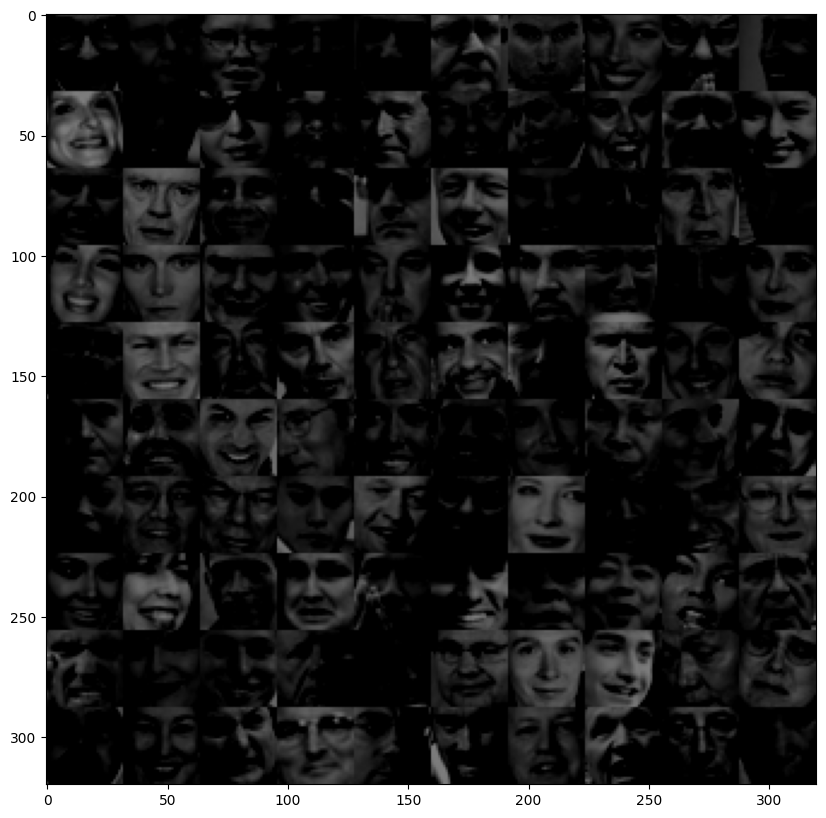

In [69]:
displayData(X)

### PCA on faces


In [70]:
# Feature normalize
means, stds, X_norm = featureNormalize(X)
# RUN SVD
U, S, V = getUSV(X_norm)

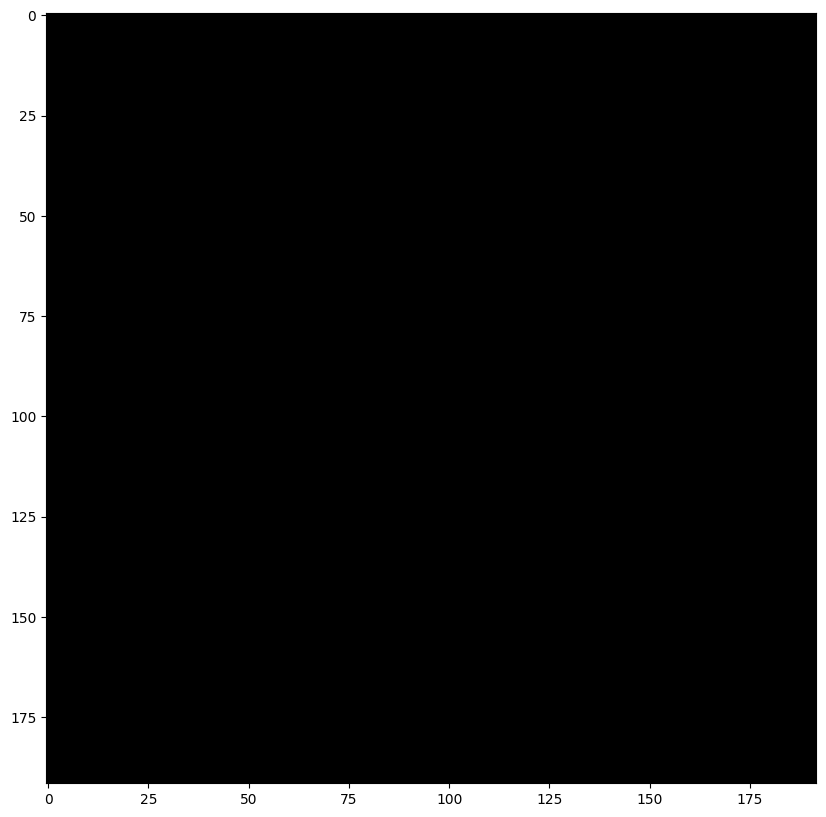

In [71]:
# Visualize the top 36 eigenvectors found
# "Eigenfaces" lol
displayData(U[:,:36].T,mynrows=6,myncols=6)


###Dimensionality Reduction

In [73]:
z = projectData(X_norm, U, K=36)
# Project each image down to 36 dimensions

In [74]:
#Attempt to recver the original data
X_rec = recoverData(z, U, K=36)

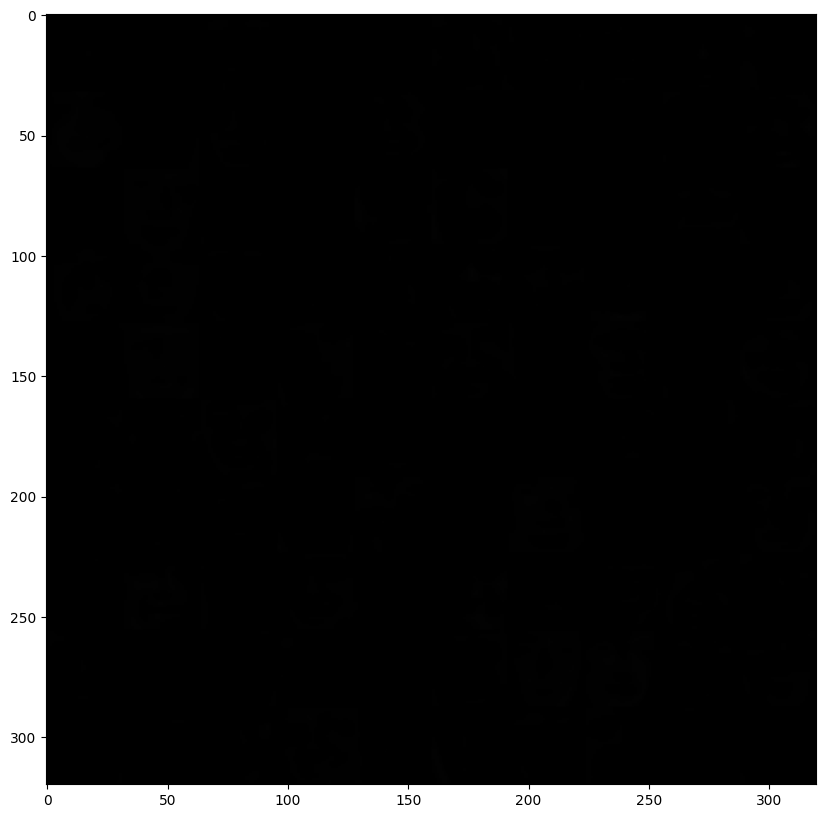

In [75]:
# Plot the dimension-reduced data
displayData(X_rec)

### PCA for visualization


In [76]:
# Here we display the 16 color clusters from before in 2D because a 3D
# display (r, g, b) is too cumbersome to look at.
# PCA projects the 3D into 2D to visualize.



# Recall "A" is the original image unrolled, shape (16384, 3)
# and "idxs" is shape (16384, 1) with entries in [0, 15]
#Feature-normalize A, save it as A_norm
# Feature normalize

means, stds, A_norm = featureNormalize(A)

# Run SCD
U, S, V = getUSV(A_norm)

In [77]:
# Use PCA to go from 3->2 dimensions
z = projectData(A_norm, U, 2)

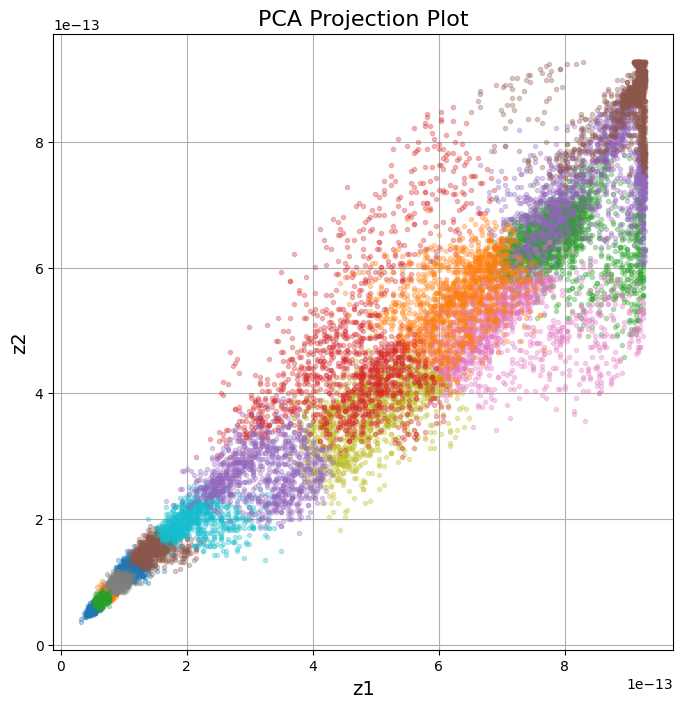

In [80]:
# Make the 2D plot
subX = []
for x in range(len(np.unique(idxs))):
  subX.append(np.array([A[i] for i in range(A.shape[0]) if idxs[i] == x]))

fig = plt.figure(figsize=(8,8))
for x in range(len(subX)):
  newX = subX[x]
  plt.plot(newX[:, 0], newX[:, 1], '.', alpha=0.3)
plt.xlabel('z1',fontsize=14)
plt.ylabel('z2',fontsize=14)
plt.title('PCA Projection Plot',fontsize=16)
plt.grid(True)